## Real/Fake News Classifier using Machine Learning

Product manager wants to include a feature in the company's news app where news articles that are not real will be flagged as fake news. In order to achieve this, a classification model has been created using machine learning. Specifically, a supervised learning model using Logistic Regression has been created. The accuracy of the model is 92%, which may indicate slight overfitting at first glance. However, appropriate measures have been taken to reduce/eliminate the possibilty of overfitting (5-fold cross validation on training data) and/or data leakage (creating a pipeline for TF-IDF vectorization).



## Preparing Colab Notebook for Analysis

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load datasets - Change file path
df_true_news = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CDAP2025/True_stories.csv")
df_fake_news = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CDAP2025/Fake_stories.csv")

Mounted at /content/drive


## Check Data Structure

In [3]:
# Check data shape for both datasets to assess data imbalance
print(df_true_news.shape)
print(df_fake_news.shape)

(21417, 4)
(23481, 4)


In [4]:
# Describe both datasets
print(df_true_news.describe())
print(df_fake_news.describe())

                                                    title  \
count                                               21417   
unique                                              20826   
top     Factbox: Trump fills top jobs for his administ...   
freq                                                   14   

                                                     text       subject  \
count                                               21417         21417   
unique                                              21192             2   
top     (Reuters) - Highlights for U.S. President Dona...  politicsNews   
freq                                                    8         11272   

                      date  
count                21417  
unique                 716  
top     December 20, 2017   
freq                   182  
                                                    title   text subject  \
count                                               23481  23481   23481   
unique               

In [5]:
# Check datapoints in both datasets
print(df_true_news.head())
print(df_fake_news.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   
                                               title  \
0   Donald Trump Sends Out Embarrassing Ne

## Data Processing

In [6]:
# Add labels to distinguish between true and fake news
df_true_news["label"] = 1
df_fake_news["label"] = 0

# Merge the true news and fake news dataset into one dataset and include only relevant columns
df_news = pd.concat([df_true_news[["title", "text", "label"]], df_fake_news[["title", "text", "label"]]], axis=0).reset_index(drop=True)

# Reduce/remove order bias by shuffling the datapoints
df_news = df_news.sample(frac=1, random_state=42).reset_index(drop=True)
df_news.head(10)

,title,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,0
5,"As private lawyer, Trump high court pick was f...",WASHINGTON (Reuters) - As a lawyer in private ...,1
6,Yemeni Salafist imam killed in Aden: sources,ADEN (Reuters) - A Salafist imam was shot dead...,1
7,FBI says witnesses in U.S. probe into Malaysia...,KUALA LUMPUR (Reuters) - Potential witnesses t...,1
8,An Easy To Read Chart Shows How Bernie Sanders...,The goal of socialism is communism. -Vladimi...,0
9,MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...,Opposing views and beliefs has much of this co...,0


In [7]:
# Check if there is any missing data in the text column and remove any nulls if they are in the text column
print("Missing values in text column:", df_news['text'].isnull().sum())
df_news = df_news[df_news['text'].notnull()]

Missing values in text column: 0


In [41]:
# Define a text cleaning function
def clean_text(text):
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    return text.lower()  # Convert to lowercase for uniformity

# Combine title and text, then clean
df_news["full_text"] = (df_news["title"] + " " + df_news["text"]).fillna("")
df_news["cleaned_text"] = df_news["full_text"].apply(clean_text)

## Logistic Regression Model

In [42]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(df_news, test_size=0.2, random_state=42)

# Extract features and labels for training and testing
X_train = train_data["cleaned_text"]
y_train = train_data["label"]
X_test = test_data["cleaned_text"]
y_test = test_data["label"]

In [43]:
# Define a pipeline for TF-IDF vectorization and Logistic Regression - Creating the pipeline helps reduce data leakage because TF-IDF is learned only on the training data, as seen in the next code chunk
pipeline = make_pipeline(
    TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english'), # Commonly used stop words are removed to reduce noise from the data. Used bigrams to improve context, increasing n-gram value becomes computationally expensive
    LogisticRegression(random_state=42, max_iter=1000, C=0.003)) # Increased regularization by lowering value of parameter C to reduce overfitting

In [44]:
# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy') # 10-fold cross validation is the gold standard, however it is computationally expensive. Running this line will take about 3-4 minutes

# Print cross-validation results
print("5-Fold Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation of CV Accuracy:", cv_scores.std())

5-Fold Cross-Validation Scores: [0.91578508 0.91160913 0.91648107 0.90853404 0.91633022]
Mean CV Accuracy: 0.9137479082478519
Standard Deviation of CV Accuracy: 0.003163775773470203


The mean accuracy of the cross validations shows that the model is generalizing well. The model would need tweaks if the k-fold cross validation accuracy varies significantly amongst the folds or against the model accuracy.


Accuracy on Test Data: 0.9251670378619153

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      4669
           1       0.97      0.87      0.92      4311

    accuracy                           0.93      8980
   macro avg       0.93      0.92      0.92      8980
weighted avg       0.93      0.93      0.92      8980



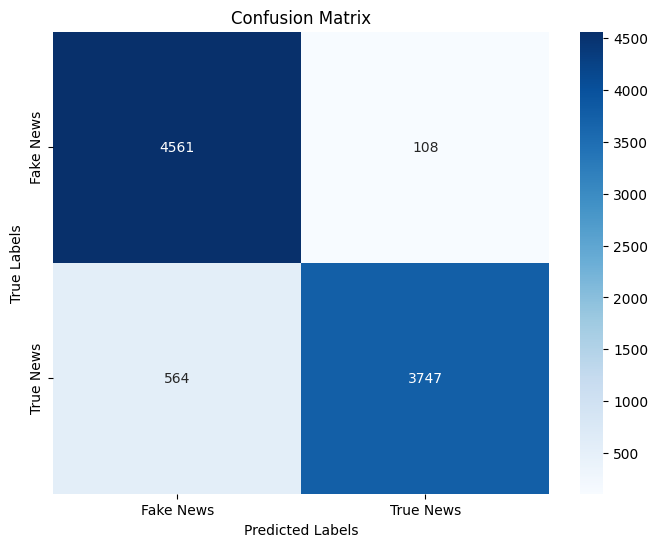

In [45]:
# Train the final model on the full training set
pipeline.fit(X_train, y_train)

# Predict on the test data
y_pred = pipeline.predict(X_test)

# Evaluate the model on the test set
print("\nAccuracy on Test Data:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Test Model on Unseen Data

In [48]:
# Input title and text of any news article
title = input("Enter the title of the news article: ") # Do not input text here, instead run the entire code chunk and type or paste text in the output text box
text = input("Enter the text of the news article: ") # Do not input text here, instead run the entire code chunk and type or paste text in the output text box

# Combine and clean text
full_text = title + " " + text
cleaned_text = clean_text(full_text)  # Maintains data structure consistency with that of the model

# Predict using trained pipeline
prediction = pipeline.predict([cleaned_text])[0]

# Display the result
result = "True News" if prediction == 1 else "Fake News"
print(f"Classified as: {result}")

Enter the title of the news article: Vance Wields Threat of Sanctions, Military Action to Push Putin Into Ukraine Deal
Enter the text of the news article: The vice president said Ukraine must have “sovereign independence.”
Classified as: True News


This model is currently a minimum viable product (MVP) and predicts whether a news article is "True News" or "Fake News" based on patterns learned from the training data. While the model has high accuracy, precision, and recall, its predictions may not be always perfect. The current iteration of the model is slightly biased towards predicting fake news and could incorrectly classify real news as fake.

Potential limitations include:
 - Biases in the training data, such as overrepresentation of certain styles or sources.
 - Differences in tone, structure, or vocabulary between the input article and the training dataset.
 - Misclassification of ambiguous articles or those with sensationalist language.

The model will be improved over time. Future enhancements could include:
- Expanding the training dataset to include more diverse sources, tones, and styles of articles.
- Fine-tuning the model using advanced techniques such as transformer-based architectures (e.g., BERT), because sometimes "Attention is All You Need".
- Incorporating domain-specific knowledge to better distinguish real from fake news.
- Improving explainability by showing which features (e.g., words or phrases) influenced each prediction.
- Building additional robustness against adversarial inputs, such as manipulated or noisy data.

